##### Ablation study on the inclusion of intersectional socio-demographic data

In [7]:
import pathlib
import pandas as pd
import os
import re

model_name = 'Llama'
is_cot = False

results_base_path = pathlib.Path(f'predictions/cleaned')
results_socdem_base_path = pathlib.Path(f'predictions_dem/{model_name}/cleaned')
socio_demographic_variables = ['gender', 'race','political']

In [8]:
def filter_full_dataset_by_socio_demographic_levels(df, socio_demographic_variables):
    """
    Filter the DataFrame by specifying the demographic variables
    """
    filtered_df = df[df['demographics'] == socio_demographic_variables].reset_index(drop=True)
    return filtered_df 

In [9]:
def read_all_model_datasets(model_name, is_cot, results_base_path, results_socdem_base_path):
    """
    Read all datasets for the specified model and CoT setting.
    Returns a dictionary with key: dict, where key is the socio-demographic variable combination
    """
    all_output_dfs = {}
    is_cot_str = 'CoT' if is_cot else 'noCoT'
    # Read the dataset for the baseline.
    df_baseline_path = results_base_path / f'cleaned_predictions_{model_name}_{is_cot_str}_baseline.csv'
    all_output_dfs['baseline'] = pd.read_csv(df_baseline_path)
    # Read the datasets for the socio-demographic variables.
    all_output_df_names = os.listdir(results_socdem_base_path)
    all_output_df_names = [file for file in all_output_df_names if file.startswith(f'cleaned_predictions_{model_name}_{is_cot_str}') and file.endswith('.csv')]
    for df_name in all_output_df_names:
        match = re.search(r'cleaned_predictions_(.*)_(CoT|noCoT)_(.*).csv', df_name)
        if match:
            socio_demographic_variables = match.group(3)
            df_path = results_socdem_base_path / df_name
            all_output_dfs[socio_demographic_variables] = pd.read_csv(df_path)
    return all_output_dfs

In [10]:
from copy import deepcopy

def filter_out_missing_rows(all_model_datasets, print_all=False):
    # Create a deep copy to avoid modifying the original datasets
    all_model_datasets_filtered = deepcopy(all_model_datasets)
    
    # Dictionary to store missing rows for each dataset
    missing_rows_dict = {}
    
    # For each dataset, identify (postId, annId) pairs that contain prediction -1
    all_missing_rows = set()
    for key, df in all_model_datasets.items():
        # Find rows where prediction is -1 and extract postId, annId as tuples
        missing_tuples = list(zip(df[df['prediction'] == -1]['postId'], 
                                  df[df['prediction'] == -1]['annId']))
        
        # Store the missing tuples for this dataset
        missing_rows_dict[key] = missing_tuples
        if print_all:
            print(f"Missing rows in {key}: {len(missing_tuples)}")
        # Add to the global set of missing rows
        all_missing_rows.update(missing_tuples)
        
    print(f"Total unique missing rows across all datasets: {len(all_missing_rows)} and valid rows: {len(all_model_datasets_filtered['baseline']) - len(all_missing_rows)}")
    
    # Remove rows with missing predictions from all datasets
    for key, df in all_model_datasets_filtered.items():
        # Filter out rows where (postId, annId) is in the set of all missing rows
        df_filtered = df[~df.set_index(['postId', 'annId']).index.isin(all_missing_rows)]
        all_model_datasets_filtered[key] = df_filtered.reset_index(drop=True)
    
    return all_model_datasets_filtered

In [11]:
all_model_datasets = read_all_model_datasets(model_name, is_cot, results_base_path, results_socdem_base_path)
all_model_datasets_filtered = filter_out_missing_rows(all_model_datasets)

Total unique missing rows across all datasets: 8 and valid rows: 3086


In [12]:
all_model_datasets.keys()

dict_keys(['baseline', 'gender', 'gender_political', 'gender_race_political', 'race', 'political', 'race_political', 'gender_race'])

In [13]:
socio_demographic_variables

['gender', 'race', 'political']

In [14]:
from collections import Counter
Counter(all_model_datasets_filtered['gender_race_political']['demographics'])

Counter({"{'gender': 'man', 'race': 'white', 'political leaning': 'liberal'}": 504,
         "{'gender': 'man', 'race': 'white', 'political leaning': 'conservative'}": 504,
         "{'gender': 'woman', 'race': 'white', 'political leaning': 'liberal'}": 414,
         "{'gender': 'woman', 'race': 'white', 'political leaning': 'conservative'}": 382,
         "{'gender': 'man', 'race': 'black', 'political leaning': 'liberal'}": 373,
         "{'gender': 'woman', 'race': 'black', 'political leaning': 'liberal'}": 330,
         "{'gender': 'man', 'race': 'black', 'political leaning': 'neutral'}": 150,
         "{'gender': 'woman', 'race': 'white', 'political leaning': 'neutral'}": 138,
         "{'gender': 'man', 'race': 'white', 'political leaning': 'neutral'}": 96,
         "{'gender': 'man', 'race': 'black', 'political leaning': 'conservative'}": 78,
         "{'gender': 'woman', 'race': 'black', 'political leaning': 'conservative'}": 57,
         "{'gender': 'woman', 'race': 'black', 'p

In [15]:
# Compute Cohen kappa 
from sklearn.metrics import cohen_kappa_score
def compute_intersectionality_cohen_kappa(all_model_datasets_filtered, socio_demographic_variables):
    """
    Compute Cohen Kappa for the dataset containing all socio-demographic variables to all other datasets.
    """
    # Identify the intersectionality dataset
    all_socdem_string = '_'.join(socio_demographic_variables)
    intersectionality_dataset = all_model_datasets_filtered[all_socdem_string]
    all_model_datasets_filtered = {key: df for key, df in all_model_datasets_filtered.items() if key != all_socdem_string}
    
    # Extract all combinations of socio-demographic variables
    all_combinations = intersectionality_dataset['demographics'].unique()
    
    # Initialize a dictionary to store Cohen Kappa values
    all_results = {} # ('socio-demographic variable combination': {'all': {'kappa': kappa_value, 'exact_match': exact_match_count}, 'white_male_left': {'kappa': kappa_value, 'exact_match': exact_match_count}, ......})
    
    # Compute overall Cohen Kappa and Cohen Kappa for each socio-demographic variable combination. Also report number of instances and exact matches
    # Iterate through each dataset and compute Cohen Kappa.
    for key, df in all_model_datasets_filtered.items():
        # Extract the predictions from both datasets, ensuring they are aligned using postId and annId
        merged_df = pd.merge(intersectionality_dataset[['postId', 'annId', 'prediction']], 
                            df[['postId', 'annId', 'prediction']], 
                            on=['postId', 'annId'], 
                            suffixes=('_intersectional', '_current'))
        
        intersectionality_predictions = merged_df['prediction_intersectional']
        df_predictions = merged_df['prediction_current']        
        # Count number of items where we have exact match 
        exact_match_count = int((intersectionality_predictions == df_predictions).sum())
        exact_match_count_perc = exact_match_count / len(intersectionality_predictions) * 100
        kappa_value = cohen_kappa_score(intersectionality_predictions, df_predictions)
        all_results[key] = {}
        all_results[key]['all'] = {'kappa': kappa_value, 
                                   'exact_match': exact_match_count, 
                                   'exact_match_perc': round(exact_match_count_perc, 2), 
                                   'count': len(intersectionality_predictions)}
        # Now consider all combinations of socio-demographic variables, filter the dataset and compute Cohen Kappa for them as well.
        for socdem_combination in all_combinations:
            # Filter the intersectionality dataset by the socio-demographic variable combination
            filtered_intersectionality_df = filter_full_dataset_by_socio_demographic_levels(intersectionality_dataset, socdem_combination)
            
            # Merge the filtered datasets
            merged_filtered_df = pd.merge(filtered_intersectionality_df[['postId', 'annId', 'prediction']], 
                                          df[['postId', 'annId', 'prediction']], 
                                          on=['postId', 'annId'], 
                                          suffixes=('_intersectional', '_current'))
            if not merged_filtered_df.empty:
                intersectionality_predictions_filtered = merged_filtered_df['prediction_intersectional']
                df_predictions_filtered = merged_filtered_df['prediction_current']
                
                exact_match_count_filtered = int((intersectionality_predictions_filtered == df_predictions_filtered).sum())
                exact_match_count_perc_filtered = exact_match_count_filtered / len(intersectionality_predictions_filtered) * 100
                kappa_value_filtered = cohen_kappa_score(intersectionality_predictions_filtered, df_predictions_filtered)
                all_results[key][f"{socdem_combination}"] = {'kappa': kappa_value_filtered, 
                                                              'exact_match': exact_match_count_filtered, 
                                                              'exact_match_perc': round(exact_match_count_perc_filtered, 2), 
                                                              'count': len(intersectionality_predictions_filtered)}
                            
    # Now consider filtered versions of the datasets and compute Cohen Kappa for them as well
    return all_results

In [16]:
all_results_cohen = compute_intersectionality_cohen_kappa(all_model_datasets_filtered, socio_demographic_variables)

In [17]:
all_results_cohen

{'baseline': {'all': {'kappa': 0.9432540528980067,
   'exact_match': 3021,
   'exact_match_perc': 97.89,
   'count': 3086},
  "{'gender': 'woman', 'race': 'black', 'political leaning': 'liberal'}": {'kappa': 0.9438297872340425,
   'exact_match': 324,
   'exact_match_perc': 98.18,
   'count': 330},
  "{'gender': 'man', 'race': 'black', 'political leaning': 'neutral'}": {'kappa': 0.9653579676674365,
   'exact_match': 148,
   'exact_match_perc': 98.67,
   'count': 150},
  "{'gender': 'man', 'race': 'black', 'political leaning': 'liberal'}": {'kappa': 0.9203903839810629,
   'exact_match': 362,
   'exact_match_perc': 97.05,
   'count': 373},
  "{'gender': 'man', 'race': 'black', 'political leaning': 'conservative'}": {'kappa': 0.9367396593673966,
   'exact_match': 76,
   'exact_match_perc': 97.44,
   'count': 78},
  "{'gender': 'woman', 'race': 'black', 'political leaning': 'neutral'}": {'kappa': 0.9223946784922394,
   'exact_match': 34,
   'exact_match_perc': 97.14,
   'count': 35},
  "{'g

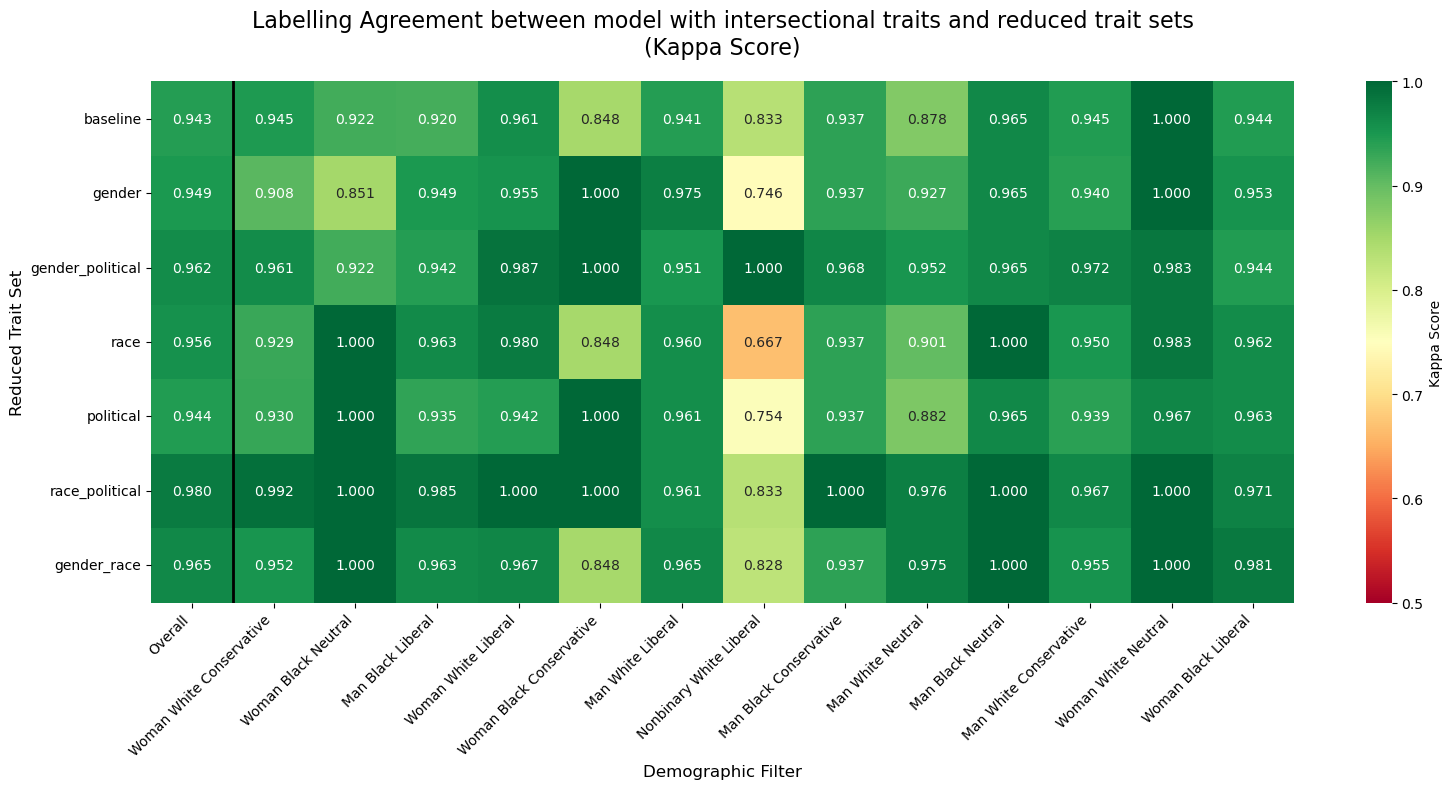

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Your data
data = all_results_cohen
def parse_filter_key(key):
    """Parse the filter key to create a readable column name"""
    if key == 'all':
        return 'Overall'
    
    # Parse the dictionary string
    try:
        # Remove quotes and braces, split by commas
        key_clean = key.strip("{}").replace("'", "").replace('"', '')
        parts = [part.strip() for part in key_clean.split(',')]
        
        # Extract values
        values = []
        for part in parts:
            if ':' in part:
                value = part.split(':')[1].strip()
                values.append(value)
        
        return ' '.join(values).title()
    except:
        return key

def create_visualization_table(data, metric='kappa'):
    """Create a table visualization of the results"""
    
    # Get all unique filter keys across all trait sets
    all_filters = set()
    for trait_set in data.keys():
        all_filters.update(data[trait_set].keys())
    
    # Create readable column names
    filter_mapping = {f: parse_filter_key(f) for f in all_filters}
    
    # Create the dataframe
    rows = []
    for trait_set in data.keys():
        row = {'Trait Set': trait_set}
        for filter_key in all_filters:
            col_name = filter_mapping[filter_key]
            if filter_key in data[trait_set]:
                row[col_name] = data[trait_set][filter_key][metric]
            else:
                row[col_name] = np.nan
        rows.append(row)
    
    df = pd.DataFrame(rows)
    df = df.set_index('Trait Set')
    
    return df, filter_mapping

# Create visualization for kappa metric
kappa_df, filter_mapping = create_visualization_table(data, 'kappa')

# Reorganize columns to put "Overall" first
if 'Overall' in kappa_df.columns:
    cols = ['Overall'] + [col for col in kappa_df.columns if col != 'Overall']
    kappa_df = kappa_df[cols]

# Create a proper heatmap visualization
plt.figure(figsize=(16, 8))

# Set appropriate bounds for kappa scores
vmin, vmax = 0.5, 1.0
cmap = 'RdYlGn'

# Create the heatmap
mask = kappa_df.isnull()
ax = sns.heatmap(kappa_df, 
                annot=True, 
                fmt='.3f',
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                mask=mask,
                cbar_kws={'label': 'Kappa Score'},
                square=False)

# Add a vertical line to separate "Overall" from other columns
if 'Overall' in kappa_df.columns:
    plt.axvline(x=1, color='black', linewidth=2)

plt.title('Labelling Agreement between model with intersectional traits and reduced trait sets\n(Kappa Score)', 
          fontsize=16, pad=20)
plt.xlabel('Demographic Filter', fontsize=12)
plt.ylabel('Reduced Trait Set', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()


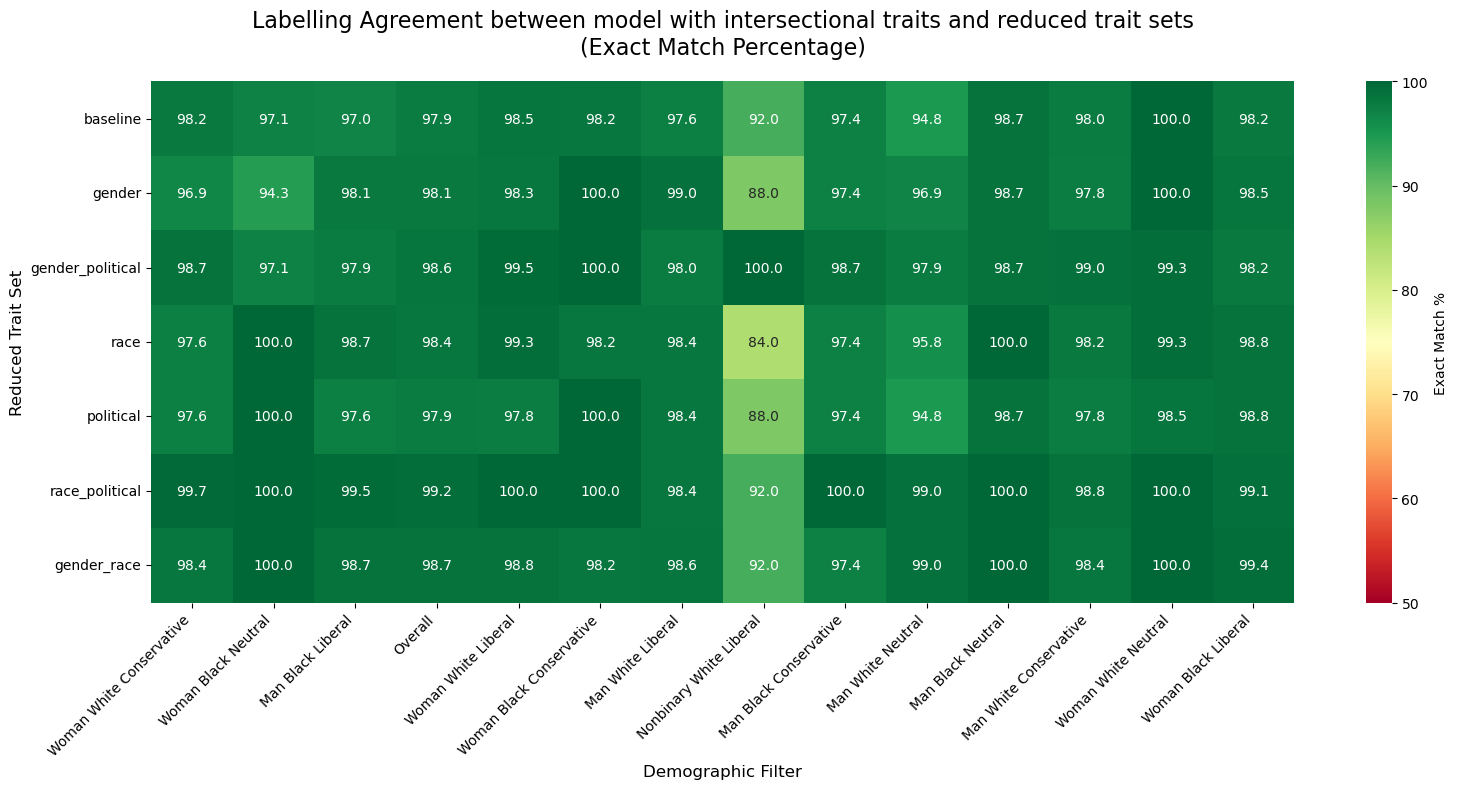

In [32]:
# Create a figure for the exact match percentage heatmap
plt.figure(figsize=(16, 8))

# Create the heatmap for exact match percentage
sns.heatmap(exact_match_df, 
            annot=True, 
            fmt='.1f',
            cmap='RdYlGn',
            vmin=50,
            vmax=100,
            mask=exact_match_df.isnull(),
            cbar_kws={'label': 'Exact Match %'})

plt.title('Labelling Agreement between model with intersectional traits and reduced trait sets\n(Exact Match Percentage)', 
          fontsize=16, pad=20)
plt.xlabel('Demographic Filter', fontsize=12)
plt.ylabel('Reduced Trait Set', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()